# CNN con CIFAR-10

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class. 

Extraído de https://www.cs.toronto.edu/~kriz/cifar.html

## Carga de datos

In [14]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ToTensor convierte PIL.Image a torch.Tensor
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

print(f'Train: {len(train_dataset)} imagenes')
print(f'Test : {len(test_dataset)} imagenes')
print(f'Shape de una imagen: {train_dataset[0][0].shape}  (C x H x W)')

Train: 50000 imagenes
Test : 10000 imagenes
Shape de una imagen: torch.Size([3, 32, 32])  (C x H x W)


In [2]:
CLASSES = train_dataset.classes
print('Clases:', CLASSES)

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


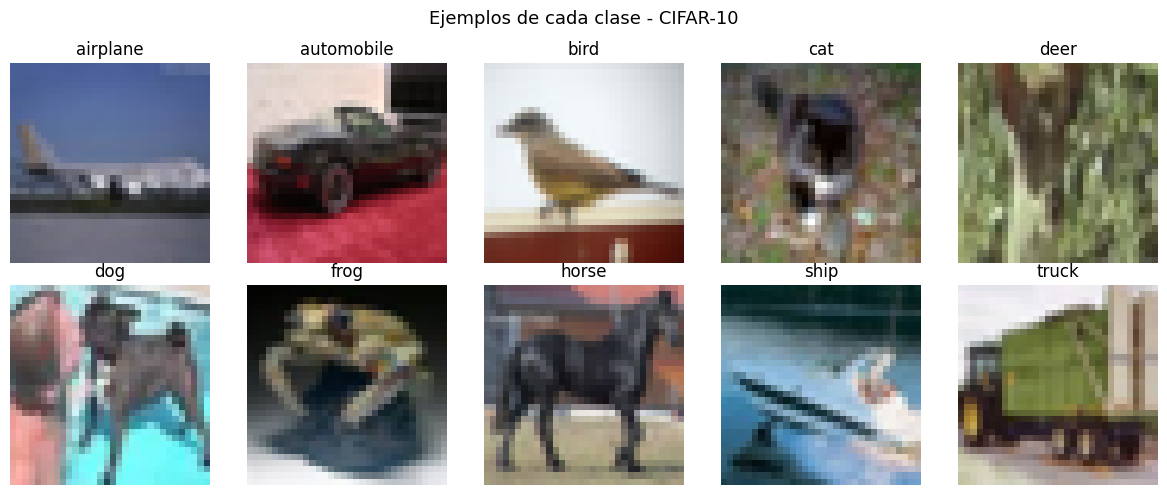

In [4]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, cls_idx in zip(axes.flat, range(10)):
    idx = random.choice([i for i, (_, y) in enumerate(train_dataset) if y == cls_idx])
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[label])
    ax.axis('off')
plt.suptitle('Ejemplos de cada clase - CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

## Modelo

In [20]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
# Una clase configurable para la creación de los modelos. 
# Recibe lista de filtros por capa y ek tamaño de la capa oculta y el dropout.
# Para cada capa hacemos Conv2d + ReLU + MaxPool2d(2) y al final aplanamos y pasamos por una capa oculta con dropout antes de la capa de salida.
class CNNModel(nn.Module):
    def __init__(self, filters: list[int], fc_size: int, dropout: float = 0.3):
        super().__init__()

        conv_layers = []
        in_ch = 3  # 3 canales (RGB)
        for out_ch in filters:
            conv_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, stride=2),
            ]
            in_ch = out_ch
        self.features = nn.Sequential(*conv_layers)

        # Después de N capas de MaxPool2d(2), el spatial size es 32 / 2^N
        spatial = 32 // (2 ** len(filters))
        flat_size = in_ch * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Optimizador y función de pérdida

In [11]:
from torch.optim import Adam

# CrossEntropyLoss porque es un problema de clasificación multiclase.
loss_fn = nn.CrossEntropyLoss()

# Adam como optimizador.
# Como lo único que va a cambiar entre los modelos es la arquitectura, defino los demás hiperparámetros aquí.
LEARNING_RATE = 1e-3
EPOCHS        = 20
BATCH_SIZE    = 64

print(f"Loss    : CrossEntropyLoss")
print(f"Opt     : Adam  (lr={LEARNING_RATE})")
print(f"Épocas  : {EPOCHS}")
print(f"Batch   : {BATCH_SIZE}")

Loss    : CrossEntropyLoss
Opt     : Adam  (lr=0.001)
Épocas  : 20
Batch   : 64


## Entrenamiento

In [26]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def train_model(model, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct = 0.0, 0
        for images, labels in tqdm(train_loader, desc=f"Época {epoch}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(images)
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
        train_loss = running_loss / len(train_dataset)
        train_acc  = correct / len(train_dataset)

        model.eval()
        running_loss, correct = 0.0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                running_loss += loss_fn(outputs, labels).item() * len(images)
                correct += outputs.argmax(dim=1).eq(labels).sum().item()
        test_loss = running_loss / len(test_dataset)
        test_acc  = correct / len(test_dataset)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        print(f"Época {epoch:2d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")

    return history

In [27]:
def plot_curves(histories: dict):
    """Recibe un dict {nombre: history} y grafica loss y accuracy por modelo."""
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 9), sharey="row")
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (name, hist) in enumerate(histories.items()):
        epochs_range = range(1, len(hist["train_loss"]) + 1)

        # Loss
        axes[0, col].plot(epochs_range, hist["train_loss"], label="Train")
        axes[0, col].plot(epochs_range, hist["test_loss"],  label="Test")
        axes[0, col].set_title(name)
        axes[0, col].set_xlabel("Época")
        axes[0, col].set_ylabel("Loss")
        axes[0, col].legend()

        # Accuracy
        axes[1, col].plot(epochs_range, hist["train_acc"], label="Train")
        axes[1, col].plot(epochs_range, hist["test_acc"],  label="Test")
        axes[1, col].set_xlabel("Época")
        axes[1, col].set_ylabel("Accuracy")
        axes[1, col].legend()

    plt.suptitle("Curvas de aprendizaje", fontsize=13)
    plt.tight_layout()
    plt.show()

## Entrenamiento de los 3 modelos

In [19]:
# Seed para que los 3 modelos arranquen con los mismos pesos iniciales
torch.manual_seed(42)

# Red pequeña. 2 capas conv con pocos filtros
model1 = CNNModel(filters=[32, 64], fc_size=256)
print("Modelo 1: filters=[32, 64], fc_size=256")
hist1 = train_model(model1)

Modelo 1: filters=[32, 64], fc_size=256


Época  1 | Train Loss: 1.4907 | Test Loss: 1.1764


Época  5 | Train Loss: 0.8133 | Test Loss: 0.8359


Época 10 | Train Loss: 0.5290 | Test Loss: 0.8396


Época 15 | Train Loss: 0.3415 | Test Loss: 0.9627


Época 20 | Train Loss: 0.2416 | Test Loss: 1.1778


In [ ]:
# Red mediana. 3 capas conv
model2 = CNNModel(filters=[32, 64, 128], fc_size=256)
print("Modelo 2: filters=[32, 64, 128], fc_size=256")
hist2 = train_model(model2)


=== Modelo 2: filters=[32, 64, 128], fc_size=256 ===


Época  1 | Train Loss: 1.5418 | Test Loss: 1.1985


Época  5 | Train Loss: 0.7604 | Test Loss: 0.8208


Época 10 | Train Loss: 0.4756 | Test Loss: 0.7395


Época 15 | Train Loss: 0.2973 | Test Loss: 0.8850


Época 20 | Train Loss: 0.2141 | Test Loss: 1.0688


In [23]:
# Red mediana con FC más grande
model3 = CNNModel(filters=[32, 64, 128], fc_size=512)
print("Modelo 3: filters=[32, 64, 128], fc_size=512")
hist3 = train_model(model3)

Modelo 3: filters=[32, 64, 128], fc_size=512


Época  1 | Train Loss: 1.5124 | Test Loss: 1.1779


Época  5 | Train Loss: 0.6790 | Test Loss: 0.7607


Época 10 | Train Loss: 0.3531 | Test Loss: 0.8147


Época 15 | Train Loss: 0.1934 | Test Loss: 1.0002


Época 20 | Train Loss: 0.1394 | Test Loss: 1.1968


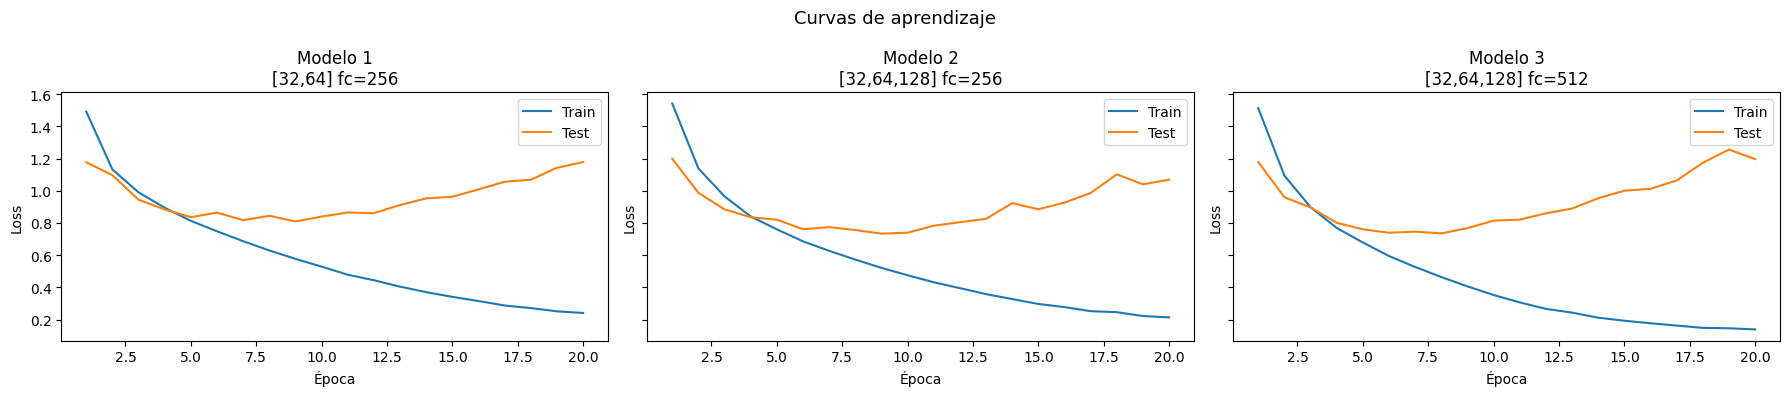

In [24]:
histories = {
    "Modelo 1\n[32,64] fc=256":    hist1,
    "Modelo 2\n[32,64,128] fc=256": hist2,
    "Modelo 3\n[32,64,128] fc=512": hist3,
}
plot_curves(histories)

## Evaluación del mejor modelo

In [ ]:
results = {
    "Modelo 1 [32,64] fc=256":     hist1["test_acc"][-1],
    "Modelo 2 [32,64,128] fc=256":  hist2["test_acc"][-1],
    "Modelo 3 [32,64,128] fc=512":  hist3["test_acc"][-1],
}

print("Test Accuracy por modelo")
for name, acc in results.items():
    print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

best_name  = max(results, key=results.get)
best_model = {"Modelo 1 [32,64] fc=256": model1,
              "Modelo 2 [32,64,128] fc=256": model2,
              "Modelo 3 [32,64,128] fc=512": model3}[best_name]

print(f"\nMejor modelo: {best_name}  →  {results[best_name]*100:.2f}% accuracy")

# Reflexiones personales

Algo que me dí cuenta, tanto en esta actividad como la otra de CNN, es que el rendimiento de las primeras épocas de la CNN es muy bueno, pero luego se estanca, y en este caso, empeora el rendimiento para el test. Me imagino que es porque el problema no es muy muy complejo. Aún así de los resultados, y de las gráficas más específicamente, podemos ver cómo los 3 modelos tienen una forma parecida: llegan a su punto más bajo de loss entre la 5ta y 8va época, y luego empieza a subir. Esto nos muestra un claro overfitting, sobre todo porque la línea que sí baja en todo momento, es la del train.

De los modelos, yo les pondría un early stop o les bajaría las épocas para evitar este overfitting. Fuera de eso, la verdad es que los 3 modelos tuvieron un performance muy parecido.